<a href="https://colab.research.google.com/github/springboardmentor1234r/B13-AirFly-Insights-Internship/blob/samhitha_serala/AirFly_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Goal:**

Analyze airline operations (2019–2023) to identify:

Delay patterns

Cancellation trends

Airline performance

Airport congestion trends

In [ ]:
#Install Kaggle

In [3]:
 !pip install kaggle --quiet

In [4]:
#Uploading kaggle.json file
from google.colab import files
files.upload()

Saving flights_sample_3m.csv to flights_sample_3m.csv


In [5]:
# creating kaggle directory
!mkdir ~/.kaggle

In [6]:
#copy Kaggle.json file
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [7]:
ls -ltr ~/.kaggle

total 0


In [8]:
!chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [9]:
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv('/content/flights_sample_3m.csv')

In [11]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [12]:
df.shape

(3000000, 32)

In [13]:
df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [16]:
#to know which has highest nulls
#and are delay colums null due to cancellations
df.isnull().sum().sort_values(ascending=False)

,0
CANCELLATION_CODE,2920860
DELAY_DUE_LATE_AIRCRAFT,2466137
DELAY_DUE_CARRIER,2466137
DELAY_DUE_SECURITY,2466137
DELAY_DUE_NAS,2466137
DELAY_DUE_WEATHER,2466137
ARR_DELAY,86198
ELAPSED_TIME,86198
AIR_TIME,86198
WHEELS_ON,79944


In [17]:
# SAMPLING
df_sample = df.sample(n=len(df), random_state=42)
df_sample.shape

(3000000, 32)

In [18]:
#checks memory in MB,"deep= true"as pandas estimates memory for object dtypes
df_sample.memory_usage(deep=True).sum() / (1024**2)

np.float64(2013.8520860671997)

In [19]:
#Converting object columns to category to optimize memory
object_cols = df_sample.select_dtypes(include='object').columns

for col in object_cols:
    df_sample[col] = df_sample[col].astype('category')

In [20]:
#optimizing numeric cols
df_sample['CANCELLED'] = df_sample['CANCELLED'].fillna(0).astype('int8')

In [21]:
# Preprocessing & Feature Engineering
df_sample.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
2945667,2021-05-04,JetBlue Airways,JetBlue Airways: B6,B6,20409,384,MCO,"Orlando, FL",JFK,"New York, NY",...,0.0,159.0,152.0,129.0,944.0,NaN,NaN,NaN,NaN,NaN
2352586,2019-11-26,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,705,FLL,"Fort Lauderdale, FL",DTW,"Detroit, MI",...,0.0,180.0,169.0,150.0,1127.0,NaN,NaN,NaN,NaN,NaN
1531260,2023-06-18,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1926,SMF,"Sacramento, CA",LAS,"Las Vegas, NV",...,0.0,80.0,73.0,59.0,397.0,NaN,NaN,NaN,NaN,NaN
941910,2019-07-28,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,4459,OKC,"Oklahoma City, OK",DTW,"Detroit, MI",...,0.0,154.0,141.0,122.0,900.0,NaN,NaN,NaN,NaN,NaN
2582125,2023-03-17,JetBlue Airways,JetBlue Airways: B6,B6,20409,277,FLL,"Fort Lauderdale, FL",SFO,"San Francisco, CA",...,0.0,384.0,402.0,374.0,2584.0,0.0,0.0,18.0,0.0,0.0


In [22]:
df_sample.memory_usage(deep=True).sum() / (1024**2)

np.float64(569.6216926574707)

In [23]:
df_sample['ARR_DELAY'] = df_sample['ARR_DELAY'].fillna(0)
df_sample['DEP_DELAY'] = df_sample['DEP_DELAY'].fillna(0)

In [24]:
df_sample['CANCELLATION_CODE'] = df_sample['CANCELLATION_CODE'].cat.add_categories('Not Cancelled')
df_sample['CANCELLATION_CODE'] = df_sample['CANCELLATION_CODE'].fillna('Not Cancelled')

In [25]:
#formatting datetime into pandas
df_sample['FL_DATE'] = pd.to_datetime(df_sample['FL_DATE'])

In [26]:
#creating derived FEATURES Month,DayOfWeek
df_sample['Month'] = df_sample['FL_DATE'].dt.month

In [27]:
df_sample['DayOfWeek'] = df_sample['FL_DATE'].dt.day_name()

In [28]:
df_sample.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,Month,DayOfWeek
2945667,2021-05-04,JetBlue Airways,JetBlue Airways: B6,B6,20409,384,MCO,"Orlando, FL",JFK,"New York, NY",...,152.0,129.0,944.0,NaN,NaN,NaN,NaN,NaN,5,Tuesday
2352586,2019-11-26,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,705,FLL,"Fort Lauderdale, FL",DTW,"Detroit, MI",...,169.0,150.0,1127.0,NaN,NaN,NaN,NaN,NaN,11,Tuesday
1531260,2023-06-18,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1926,SMF,"Sacramento, CA",LAS,"Las Vegas, NV",...,73.0,59.0,397.0,NaN,NaN,NaN,NaN,NaN,6,Sunday
941910,2019-07-28,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,4459,OKC,"Oklahoma City, OK",DTW,"Detroit, MI",...,141.0,122.0,900.0,NaN,NaN,NaN,NaN,NaN,7,Sunday
2582125,2023-03-17,JetBlue Airways,JetBlue Airways: B6,B6,20409,277,FLL,"Fort Lauderdale, FL",SFO,"San Francisco, CA",...,402.0,374.0,2584.0,0.0,0.0,18.0,0.0,0.0,3,Friday


In [29]:
df_sample['CRS_DEP_TIME'] = df_sample['CRS_DEP_TIME'].astype(str).str.zfill(4)
df_sample['DepHour'] = df_sample['CRS_DEP_TIME'].str[:2].astype(int)

In [30]:
df_sample.groupby('DepHour')['ARR_DELAY'].mean()

,ARR_DELAY
DepHour,
0,1.884595
1,4.183992
2,15.873453
3,6.758095
4,10.176101
5,-2.792177
6,-2.426490
7,-1.650141
8,-1.094223


In [31]:
df_sample['Route'] = df_sample['ORIGIN'].astype(str) + "-" + df_sample['DEST'].astype(str)

In [32]:
df_sample.groupby('Route')['ARR_DELAY'].mean().sort_values(ascending=False)

,ARR_DELAY
Route,
DEN-ABE,1080.000000
MIA-HSV,677.000000
FCA-LGA,404.250000
SFB-GFK,283.166667
CHA-MSP,206.000000
...,...
SFB-LAS,-37.200000
ABQ-SFB,-37.400000
BLI-KOA,-39.000000


In [33]:
df_sample['Route'].value_counts()

,count
Route,
SFO-LAX,5358
LAX-SFO,5212
LGA-ORD,4735
OGG-HNL,4656
ORD-LGA,4634
...,...
DTW-DAB,1
PLN-ESC,1
MYR-PWM,1


In [34]:
df_sample.to_csv("cleaned_flights_2019_2023_sample.csv", index=False)

In [35]:
#checking file saved or not
import os
os.listdir()

['.config',
 'flights_sample_3m.csv',
 'cleaned_flights_2019_2023_sample.csv',
 'sample_data']

# Visual Exploration and Delay Trends

In [38]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("cleaned_flights_2019_2023_sample.csv")

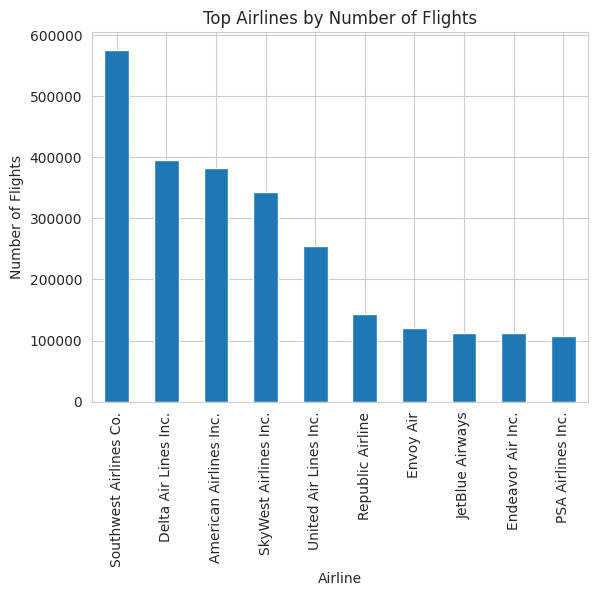

In [40]:
#Top Airlines by Number of Flights
top_airlines = df['AIRLINE'].value_counts().head(10)

plt.figure()
top_airlines.plot(kind='bar')
plt.title("Top Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.show()

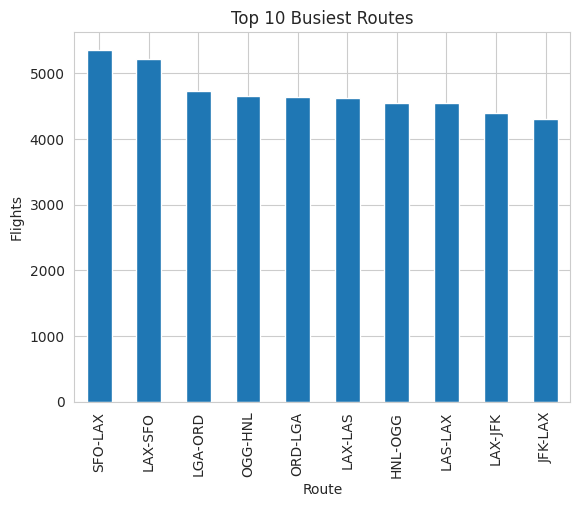

In [42]:
#Top Routes
top_routes = df['Route'].value_counts().head(10)

plt.figure()
top_routes.plot(kind='bar')
plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Flights")
plt.show()

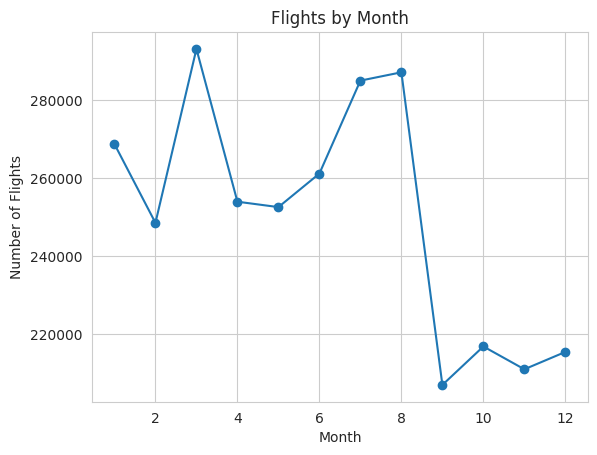

In [43]:
# busiest months
monthly_flights = df['Month'].value_counts().sort_index()

plt.figure()
monthly_flights.plot(kind='line', marker='o')
plt.title("Flights by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

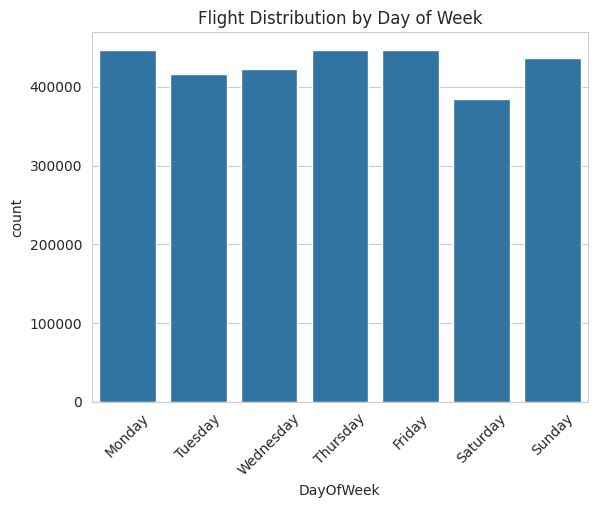

In [44]:
#Flights by Day of Week
plt.figure()
sns.countplot(x='DayOfWeek', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.title("Flight Distribution by Day of Week")
plt.xticks(rotation=45)
plt.show()


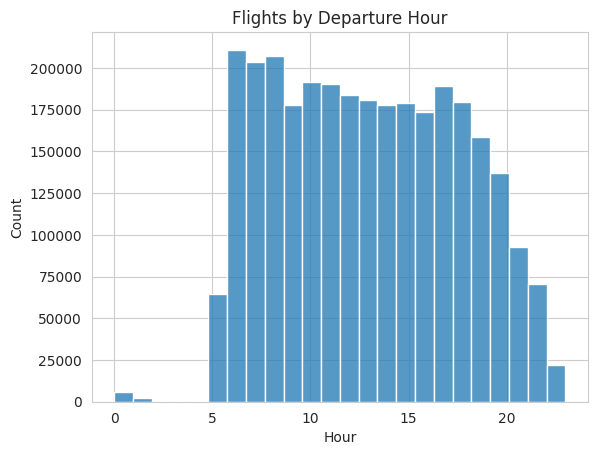

In [64]:
# FILGHTS BY HOUR
plt.figure()
sns.histplot(df['DepHour'], bins=24)

plt.title("Flights by Departure Hour")
plt.xlabel("Hour")
plt.show()

DISTRIBUTION OF ARRIVAL dELAYS


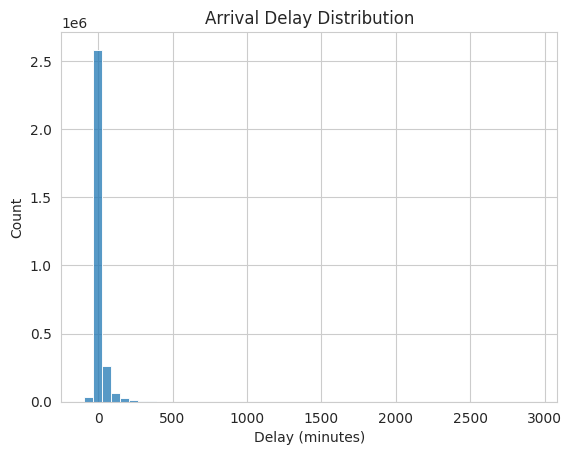

In [66]:
plt.figure()
sns.histplot(df['ARR_DELAY'], bins=50)

plt.title("Arrival Delay Distribution")
plt.xlabel("Delay (minutes)")
plt.show()

Boxplot of Delays by Airline

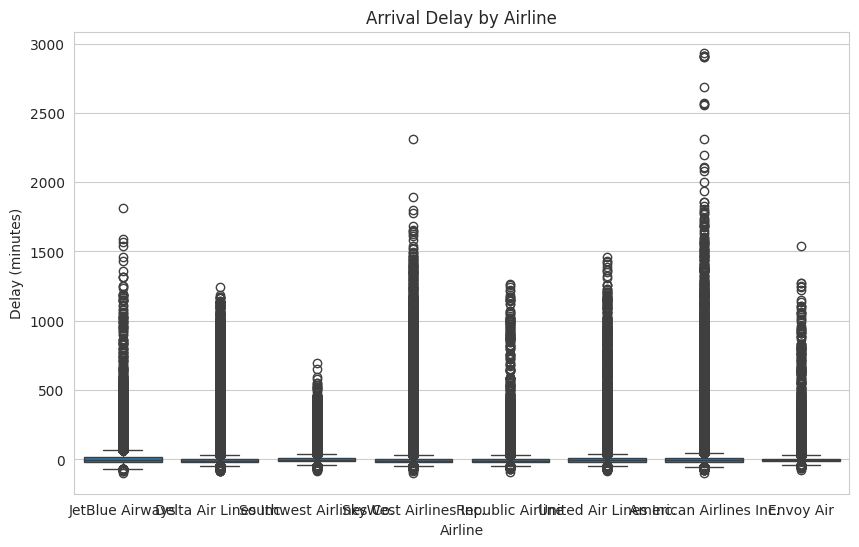

In [52]:
plt.figure(figsize=(10,6))

top_airlines = df['AIRLINE'].value_counts().head(8).index

sns.boxplot(data=df[df['AIRLINE'].isin(top_airlines)],
            x='AIRLINE',
            y='ARR_DELAY')

plt.title("Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay (minutes)")
plt.show()

Week 4: Delay Analysis: Airline and Weather

analyzingdelay causes.

Typical delay columns include:

CARRIER_DELAY

WEATHER_DELAY

NAS_DELAY

SECURITY_DELAY

LATE_AIRCRAFT_DELAY

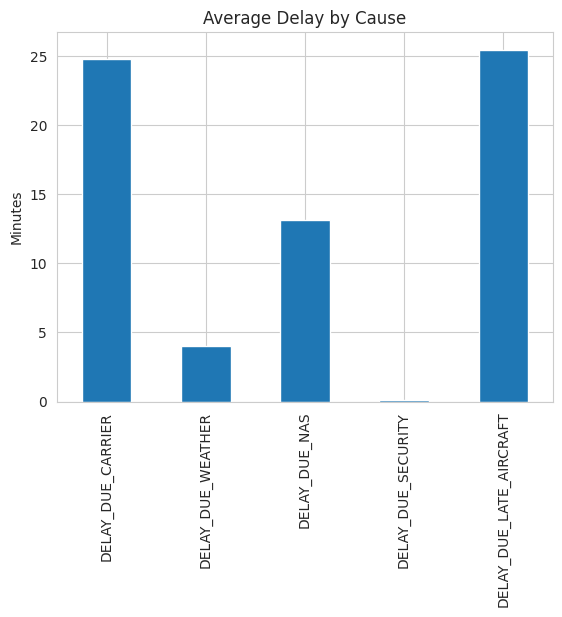

In [59]:
delay_cols = ['CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','LATE_AIRCRAFT_DELAY']

delay_avg = df[delay_cols].mean()

plt.figure()
delay_avg.plot(kind='bar')
plt.title("Average Delay by Cause")
plt.ylabel("Delay Minutes")
plt.show()

Delay by Time of Day

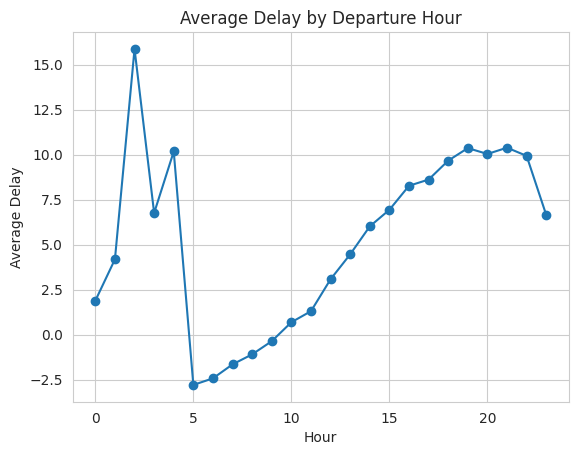

In [61]:
delay_by_hour = df.groupby('DepHour')['ARR_DELAY'].mean()

plt.figure()
delay_by_hour.plot(kind='line', marker='o')

plt.title("Average Delay by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Average Delay")
plt.show()

# IDENTIFYING Top Delay-Prone Airlines

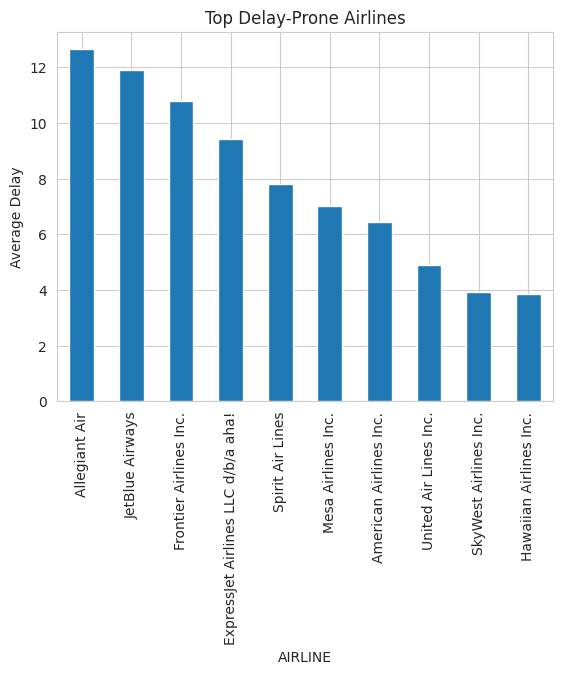

In [62]:
airline_delay = df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure()
airline_delay.plot(kind='bar')

plt.title("Top Delay-Prone Airlines")
plt.ylabel("Average Delay")
plt.show()